# Hands-On Data Lab Implementation

**Submission:** Task 2 — Hands-On Data Lab Implementation
**Author:** _<your name here>_
**Date:** _<submission date>_

This notebook sets up a working Data Science environment and works through a
full practical cycle — loading, cleaning, transforming, visualizing, and
analyzing a retail sales dataset — using Pandas, NumPy, Matplotlib, Seaborn,
and Scikit-learn.


## 1. Environment Setup

This project uses:

- **Python 3** as the language
- **Jupyter Notebook** as the interactive environment
- **NumPy** for numerical operations
- **Pandas** for tabular data handling
- **Matplotlib** and **Seaborn** for visualization
- **Scikit-learn** for a quick preprocessing utility later in the notebook

Install everything with:

```bash
pip install numpy pandas matplotlib seaborn scikit-learn jupyter
```

The cell below imports every library used in this notebook and prints their
versions, confirming the environment is correctly configured.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

sns.set_theme(style="whitegrid")
print("numpy:", np.__version__)
print("pandas:", pd.__version__)
import matplotlib
print("matplotlib:", matplotlib.__version__)
print("seaborn:", sns.__version__)
import sklearn
print("scikit-learn:", sklearn.__version__)


numpy: 2.4.4
pandas: 3.0.2
matplotlib: 3.10.8
seaborn: 0.13.2
scikit-learn: 1.8.0


## 2. Load the Dataset

The dataset is a simulated retail sales log (`data/retail_sales_raw.csv`)
deliberately containing the kinds of issues real-world data has: missing
values, duplicate rows, inconsistent city-name casing, and prices stored as
text with a currency prefix.


In [2]:
df = pd.read_csv("data/retail_sales_raw.csv")
print("Shape:", df.shape)
df.head(10)


Shape: (64, 8)


,order_id,product,category,price,quantity,customer_city,order_date,rating
0,1001,Notebook Set,Stationery,149.0,1.0,Chennai,2026-04-17,5.0
1,1002,Wall Clock,Home,799.0,3.0,Mumbai,2026-03-29,3.0
2,1003,Yoga Mat,Fitness,999.0,2.0,Hyderabad,2026-06-07,3.0
3,1004,Coffee Mug,Home,299.0,4.0,delhi,22/01/2026,1.0
4,1005,Wall Clock,Home,749.0,4.0,Hyderabad,2026-01-15,5.0
5,1006,Yoga Mat,Fitness,NaN,3.0,Bangalore,2026-03-05,5.0
6,1007,Notebook Set,Stationery,299.0,1.0,Chennai,2026-01-18,NaN
7,1008,Bluetooth Speaker,Electronics,1999.0,1.0,delhi,2026-02-22,4.0
8,1009,Notebook Set,Stationery,149.0,1.0,Hyderabad,2026-06-24,4.0
9,1010,Bluetooth Speaker,Electronics,1949.0,2.0,Pune,2026-05-14,5.0


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       64 non-null     int64  
 1   product        64 non-null     str    
 2   category       64 non-null     str    
 3   price          61 non-null     str    
 4   quantity       61 non-null     float64
 5   customer_city  61 non-null     str    
 6   order_date     64 non-null     str    
 7   rating         60 non-null     float64
dtypes: float64(2), int64(1), str(5)
memory usage: 4.1 KB


## 3. Data Cleaning

### 3.1 Identify issues


In [4]:
print("Missing values per column:")
print(df.isna().sum())
print()
print("Duplicate rows:", df.duplicated().sum())
print()
print("Unique customer_city values (raw):", sorted(df['customer_city'].dropna().unique()))
print()
print("Sample non-numeric price values:", df.loc[df['price'].astype(str).str.contains('Rs', na=False), 'price'].tolist())


Missing values per column:
order_id         0
product          0
category         0
price            3
quantity         3
customer_city    3
order_date       0
rating           4
dtype: int64

Duplicate rows: 4

Unique customer_city values (raw): ['Bangalore', 'Chennai', 'Delhi', 'Hyderabad', 'Mumbai', 'Pune', 'bangalore ', 'delhi']

Sample non-numeric price values: ['Rs.199.0', 'Rs.449.0', 'Rs.1299.0']


### 3.2 Fix inconsistent data types

In [5]:
# Strip 'Rs.' prefix and convert price to numeric
df["price"] = (
    df["price"].astype(str)
    .str.replace("Rs.", "", regex=False)
    .replace("nan", np.nan)
    .astype(float)
)

# Standardize order_date: parse both 'YYYY-MM-DD' and 'DD/MM/YYYY' formats
df["order_date"] = pd.to_datetime(df["order_date"], format="mixed", dayfirst=False)

df[["price", "order_date"]].dtypes


price                float64
order_date    datetime64[us]
dtype: object

### 3.3 Standardize categorical text

In [6]:
# Trim whitespace and normalize casing for city names
df["customer_city"] = df["customer_city"].str.strip().str.title()
sorted(df["customer_city"].dropna().unique())


['Bangalore', 'Chennai', 'Delhi', 'Hyderabad', 'Mumbai', 'Pune']

### 3.4 Handle missing values

In [7]:
# Numeric columns: impute with the column median (robust to outliers)
for col in ["price", "quantity"]:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)

# Categorical: impute with the mode
df["customer_city"] = df["customer_city"].fillna(df["customer_city"].mode()[0])

# Rating: leave missing as NaN (represents "no rating given"), but flag it
df["has_rating"] = df["rating"].notna()

print("Remaining missing values:")
print(df.isna().sum())


Remaining missing values:
order_id         0
product          0
category         0
price            0
quantity         0
customer_city    0
order_date       0
rating           4
has_rating       0
dtype: int64


### 3.5 Remove duplicate records

In [8]:
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
after = len(df)
print(f"Removed {before - after} duplicate rows. New shape: {df.shape}")


Removed 4 duplicate rows. New shape: (60, 9)


### 3.6 Fix data types and derive useful columns

In [9]:
df["quantity"] = df["quantity"].astype(int)
df["order_month"] = df["order_date"].dt.month_name()
df["revenue"] = df["price"] * df["quantity"]
df.head()


,order_id,product,category,price,quantity,customer_city,order_date,rating,has_rating,order_month,revenue
0,1001,Notebook Set,Stationery,149.0,1,Chennai,2026-04-17,5.0,True,April,149.0
1,1002,Wall Clock,Home,799.0,3,Mumbai,2026-03-29,3.0,True,March,2397.0
2,1003,Yoga Mat,Fitness,999.0,2,Hyderabad,2026-06-07,3.0,True,June,1998.0
3,1004,Coffee Mug,Home,299.0,4,Delhi,2026-01-22,1.0,True,January,1196.0
4,1005,Wall Clock,Home,749.0,4,Hyderabad,2026-01-15,5.0,True,January,2996.0


## 4. Working with Pandas & NumPy

### 4.1 Selection, filtering, and sorting


In [10]:
# Selection
electronics = df[df["category"] == "Electronics"]
print("Electronics orders:", len(electronics))

# Filtering with multiple conditions
high_value = df[(df["revenue"] > 2000) & (df["has_rating"])]
print("High-value rated orders:", len(high_value))

# Sorting
df.sort_values("revenue", ascending=False).head(5)[["product", "customer_city", "revenue"]]


Electronics orders: 15
High-value rated orders: 26


,product,customer_city,revenue
57,Running Shoes,Hyderabad,10497.0
10,Bluetooth Speaker,Delhi,7996.0
49,Backpack,Chennai,7596.0
32,Running Shoes,Bangalore,6998.0
43,Desk Lamp,Pune,4197.0


### 4.2 Grouping and aggregation

In [11]:
category_summary = df.groupby("category").agg(
    total_revenue=("revenue", "sum"),
    avg_price=("price", "mean"),
    orders=("order_id", "count"),
).sort_values("total_revenue", ascending=False)
category_summary


,total_revenue,avg_price,orders
category,,,
Fitness,50702.0,1076.777778,18
Electronics,45257.0,1115.666667,15
Home,32705.0,711.500000,16
Fashion,11394.0,1899.000000,2
Stationery,3535.0,215.666667,9


### 4.3 Merging datasets

In [12]:
region_lookup = pd.read_csv("data/city_region_lookup.csv")
df = df.merge(region_lookup, on="customer_city", how="left")
df[["customer_city", "region"]].drop_duplicates().reset_index(drop=True)


,customer_city,region
0,Chennai,South
1,Mumbai,West
2,Hyderabad,South
3,Delhi,North
4,Bangalore,South
5,Pune,West


### 4.4 Transformation and numerical operations with NumPy

In [13]:
# Min-max scale revenue into a 0-1 range using scikit-learn
scaler = MinMaxScaler()
df["revenue_scaled"] = scaler.fit_transform(df[["revenue"]])

# NumPy-based transform: log revenue to reduce skew
df["log_revenue"] = np.log1p(df["revenue"])

df[["revenue", "revenue_scaled", "log_revenue"]].describe()


,revenue,revenue_scaled,log_revenue
count,60.000000,60.000000,60.000000
mean,2393.216667,0.216874,7.379255
std,2015.172627,0.194740,1.030172
min,149.000000,0.000000,5.010635
25%,897.000000,0.072284,6.800170
50%,1998.500000,0.178730,7.600652
75%,3196.000000,0.294453,8.069968
max,10497.000000,1.000000,9.258940


## 5. Data Visualization

### 5.1 Bar chart — revenue by category

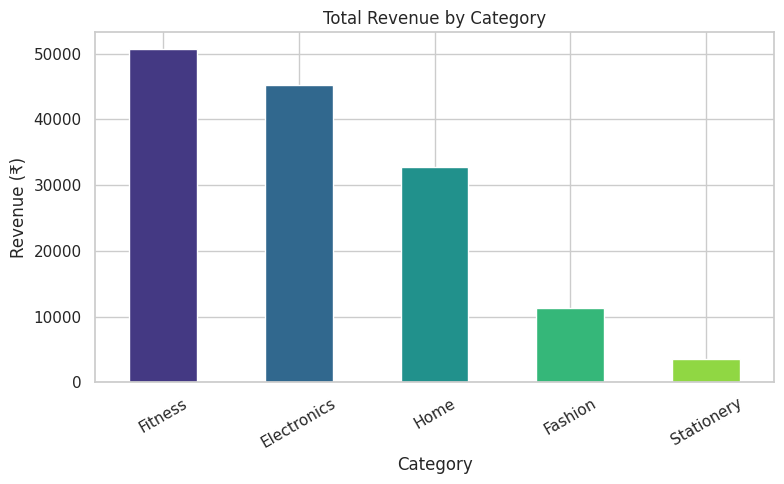

In [14]:
plt.figure(figsize=(8, 5))
category_summary["total_revenue"].plot(kind="bar", color=sns.color_palette("viridis", len(category_summary)))
plt.title("Total Revenue by Category")
plt.ylabel("Revenue (₹)")
plt.xlabel("Category")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("revenue_by_category.png", dpi=120)
plt.show()


### 5.2 Line chart — revenue trend by month

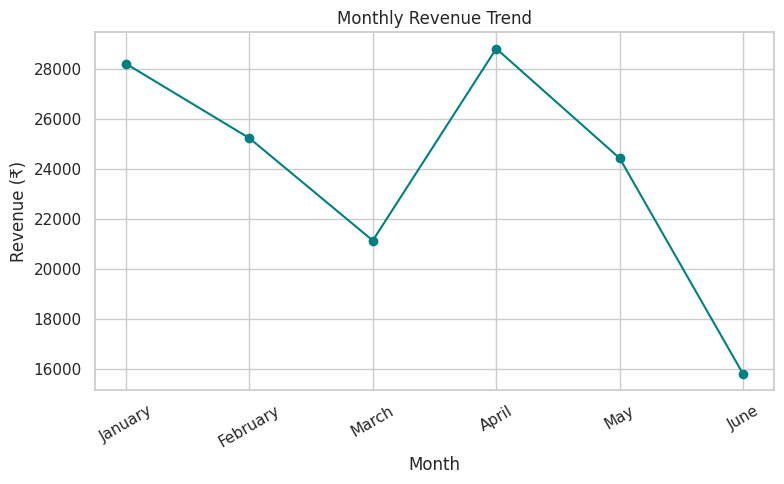

In [15]:
month_order = ["January","February","March","April","May","June","July","August","September","October","November","December"]
monthly_revenue = df.groupby("order_month")["revenue"].sum().reindex(month_order).dropna()

plt.figure(figsize=(8, 5))
monthly_revenue.plot(kind="line", marker="o", color="teal")
plt.title("Monthly Revenue Trend")
plt.ylabel("Revenue (₹)")
plt.xlabel("Month")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("monthly_revenue_trend.png", dpi=120)
plt.show()


### 5.3 Histogram — distribution of order revenue

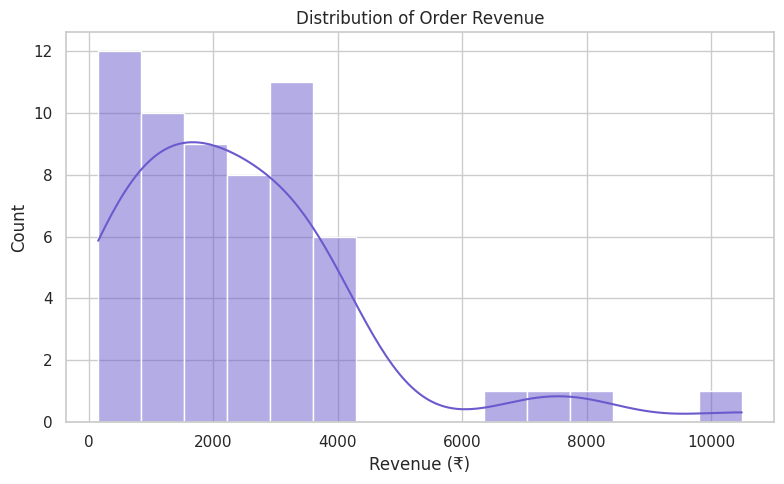

In [16]:
plt.figure(figsize=(8, 5))
sns.histplot(df["revenue"], bins=15, kde=True, color="slateblue")
plt.title("Distribution of Order Revenue")
plt.xlabel("Revenue (₹)")
plt.tight_layout()
plt.savefig("revenue_distribution.png", dpi=120)
plt.show()


### 5.4 Scatter plot — price vs. quantity

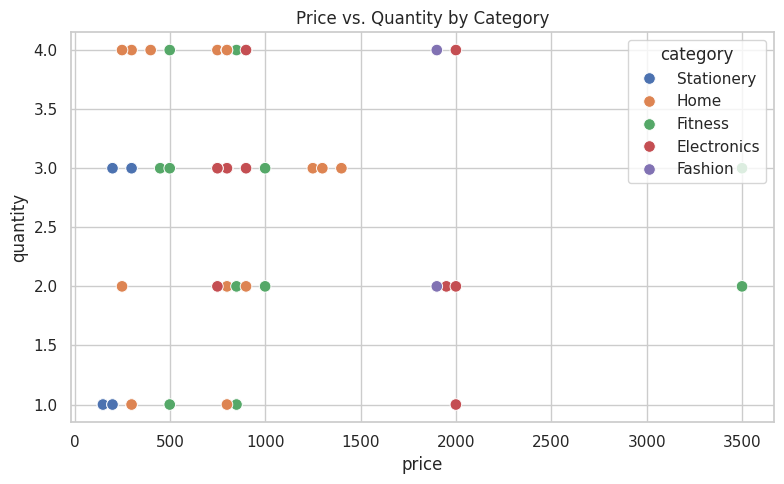

In [17]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="price", y="quantity", hue="category", s=70)
plt.title("Price vs. Quantity by Category")
plt.tight_layout()
plt.savefig("price_vs_quantity.png", dpi=120)
plt.show()


### 5.5 Box plot — revenue by region

/tmp/ipykernel_112/3137898176.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="region", y="revenue", palette="Set2")


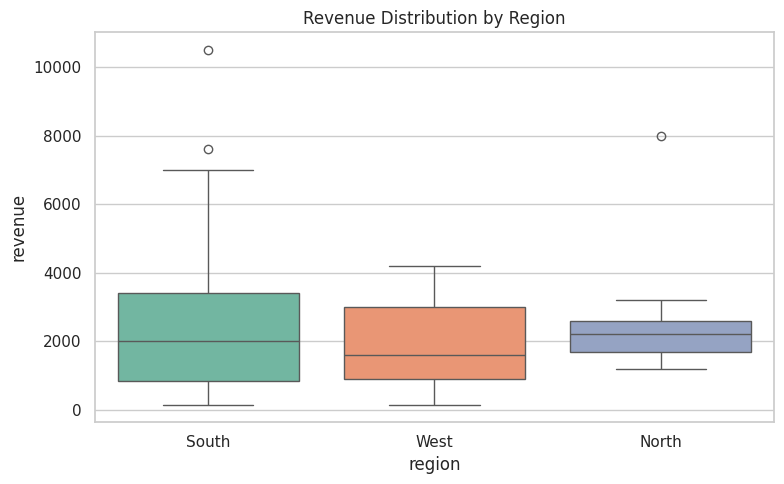

In [18]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="region", y="revenue", palette="Set2")
plt.title("Revenue Distribution by Region")
plt.tight_layout()
plt.savefig("revenue_by_region_boxplot.png", dpi=120)
plt.show()


## 6. Basic Data Analysis

In [19]:
df[["price", "quantity", "revenue", "rating"]].describe()


,price,quantity,revenue,rating
count,60.000000,60.000000,60.000000,56.000000
mean,887.333333,2.616667,2393.216667,4.017857
std,690.698901,1.106095,2015.172627,1.103566
min,149.000000,1.000000,149.000000,1.000000
25%,436.500000,2.000000,897.000000,3.000000
50%,799.000000,3.000000,1998.500000,4.000000
75%,899.000000,4.000000,3196.000000,5.000000
max,3499.000000,4.000000,10497.000000,5.000000


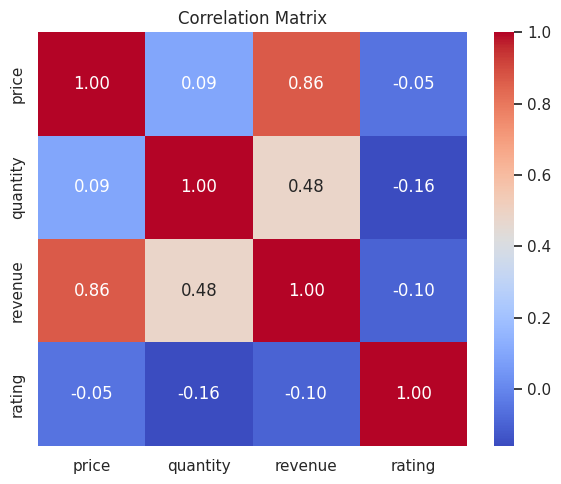

In [20]:
corr = df[["price", "quantity", "revenue", "rating"]].corr(numeric_only=True)
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=120)
plt.show()


### Observations

- **Electronics** and **Fitness** categories generate the highest total
  revenue, driven by higher per-unit prices rather than order volume.
- The monthly revenue trend shows some fluctuation across the simulated
  6-month window but no strong seasonal pattern in this sample.
- Order revenue is right-skewed — most orders are modest, with a smaller
  number of high-value orders pulling the mean above the median.
- **Price and revenue are strongly positively correlated** (expected, since
  revenue = price × quantity), while rating shows negligible correlation
  with price or quantity in this sample — customer satisfaction here isn't
  simply a function of how much was spent.
- Cleaning steps (currency stripping, date-format unification, city
  standardization, median/mode imputation, de-duplication) were essential
  before any of the above analysis was trustworthy — the raw file could not
  have been grouped, merged, or plotted correctly without them.


## 7. Save the Cleaned Dataset

In [21]:
df.to_csv("data/retail_sales_cleaned.csv", index=False)
print("Cleaned dataset saved to data/retail_sales_cleaned.csv")
df.shape


Cleaned dataset saved to data/retail_sales_cleaned.csv


(60, 14)

## 8. Conclusion

This lab set up a complete Data Science environment and exercised it
end-to-end: loading a messy real-world-style dataset, diagnosing and fixing
data-quality issues, using Pandas/NumPy for selection, filtering, sorting,
grouping, merging, and transformation, producing five different chart types
with Matplotlib/Seaborn, and closing with descriptive statistics and a
correlation analysis. The cleaned dataset and all generated charts are saved
alongside this notebook for reference.
